# Region Growing Segmentation

Region growing segments an image by starting from one or more **seed points** and repeatedly 
annexing neighboring pixels that are similar enough to the region's running mean intensity. 
Unlike global thresholding, it guarantees a spatially **connected** result.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from skimage import data

## 1. Load a Sample Image

`skimage.data.coins()` contains several coins with fairly uniform interiors on a textured background --- 
a good test case since each coin is a natural target region.

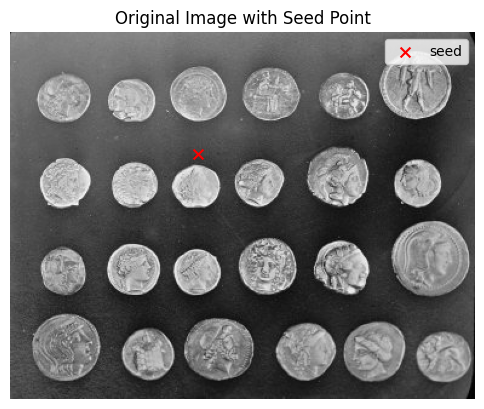

In [2]:
image = data.coins()
seed = (100, 155)  # (row, col) chosen inside one coin

plt.figure(figsize=(6, 5))
plt.imshow(image, cmap='gray')
plt.scatter([seed[1]], [seed[0]], c='red', s=50, marker='x', label='seed')
plt.title('Original Image with Seed Point')
plt.legend()
plt.axis('off')
plt.show()

## 2. Region Growing (from scratch)

A pixel $p$ is added to region $R$ if:

$$|I(p) - \mu_R| < T$$

where $\mu_R$ is the current mean intensity of the region. The mean is updated incrementally as pixels 
are added, and the search proceeds breadth-first over 4- or 8-connected neighbors.

In [3]:
def region_growing(image, seed, threshold=15, connectivity=8):
    """Seeded region growing. Returns a boolean mask the same size as `image`."""
    image = image.astype(float)
    h, w = image.shape
    visited = np.zeros((h, w), dtype=bool)
    region_mask = np.zeros((h, w), dtype=bool)

    offsets_4 = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    offsets_8 = offsets_4 + [(-1, -1), (-1, 1), (1, -1), (1, 1)]
    offsets = offsets_8 if connectivity == 8 else offsets_4

    sy, sx = seed
    region_sum, region_size = image[sy, sx], 1
    region_mean = region_sum

    queue = deque([seed])
    visited[sy, sx] = True
    region_mask[sy, sx] = True

    while queue:
        y, x = queue.popleft()
        for dy, dx in offsets:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                visited[ny, nx] = True
                if abs(image[ny, nx] - region_mean) < threshold:
                    region_mask[ny, nx] = True
                    region_sum += image[ny, nx]
                    region_size += 1
                    region_mean = region_sum / region_size
                    queue.append((ny, nx))

    return region_mask

Region size: 3045 pixels


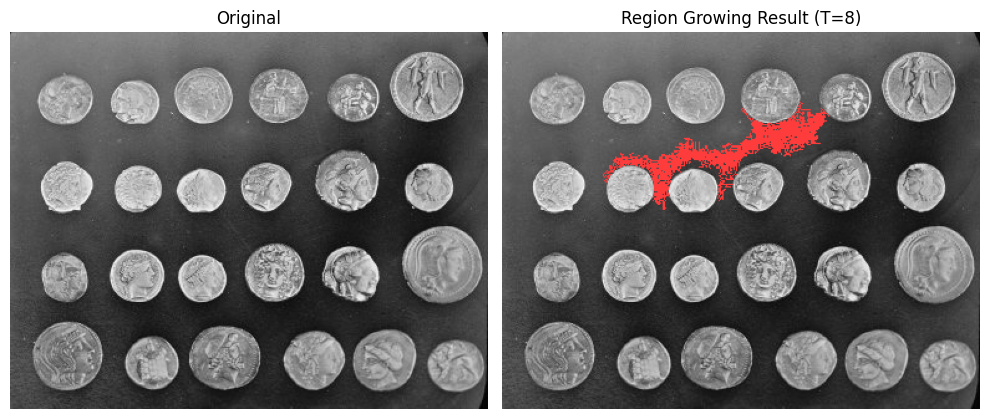

In [4]:
mask = region_growing(image, seed, threshold=8, connectivity=8)
print(f'Region size: {mask.sum()} pixels')

overlay = np.stack([image] * 3, axis=-1).astype(np.uint8)
overlay[mask] = [255, 60, 60]  # highlight the grown region in red

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(overlay)
axes[1].set_title('Region Growing Result (T=8)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Visualizing Growth Over Iterations

To see the region expand outward from the seed, record the BFS order in which pixels are added, 
then reconstruct partial masks at a few checkpoints (25%, 50%, 75%, 100% of final size).

In [5]:
def region_growing_with_snapshots(image, seed, threshold=15, connectivity=8, n_snapshots=4):
    """Same as region_growing, but also returns intermediate masks at evenly spaced checkpoints."""
    image = image.astype(float)
    h, w = image.shape
    visited = np.zeros((h, w), dtype=bool)

    offsets_4 = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    offsets_8 = offsets_4 + [(-1, -1), (-1, 1), (1, -1), (1, 1)]
    offsets = offsets_8 if connectivity == 8 else offsets_4

    sy, sx = seed
    region_sum, region_size = image[sy, sx], 1
    region_mean = region_sum

    queue = deque([seed])
    visited[sy, sx] = True
    added_order = [seed]

    while queue:
        y, x = queue.popleft()
        for dy, dx in offsets:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                visited[ny, nx] = True
                if abs(image[ny, nx] - region_mean) < threshold:
                    region_sum += image[ny, nx]
                    region_size += 1
                    region_mean = region_sum / region_size
                    queue.append((ny, nx))
                    added_order.append((ny, nx))

    total = len(added_order)
    checkpoints = [int(total * f) for f in np.linspace(1 / n_snapshots, 1, n_snapshots)]

    snapshots, mask, idx = [], np.zeros((h, w), dtype=bool), 0
    for cp_i, cp in enumerate(checkpoints):
        while idx < cp:
            ry, rx = added_order[idx]
            mask[ry, rx] = True
            idx += 1
        snapshots.append(((cp_i + 1) / n_snapshots, mask.copy()))

    return snapshots

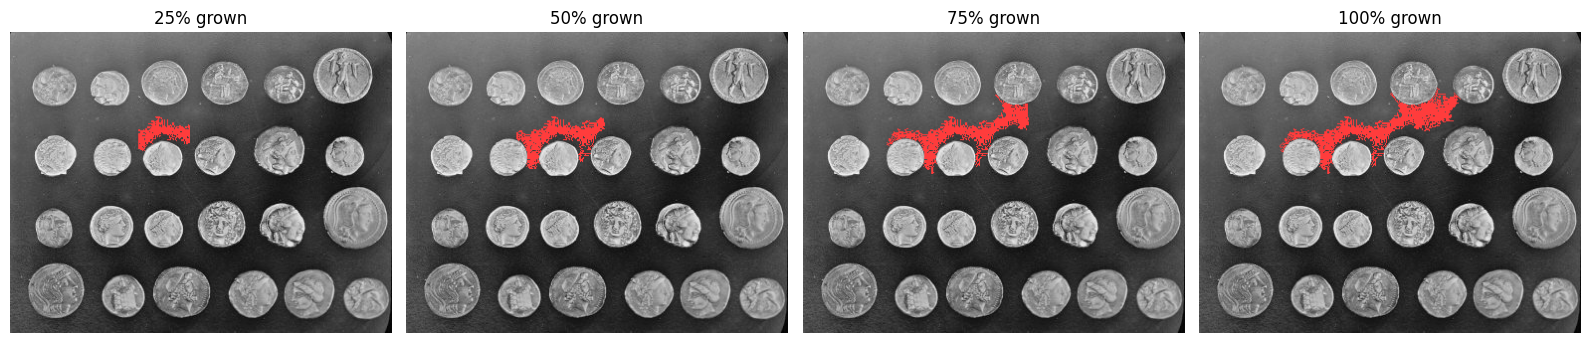

In [6]:
snapshots = region_growing_with_snapshots(image, seed, threshold=8, n_snapshots=4)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (frac, snap_mask) in zip(axes, snapshots):
    overlay = np.stack([image] * 3, axis=-1).astype(np.uint8)
    overlay[snap_mask] = [255, 60, 60]
    ax.imshow(overlay)
    ax.set_title(f'{int(frac * 100)}% grown')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Effect of the Similarity Threshold T

$T$ controls how permissive growth is:
- **Too small** $\to$ under-growth, region stops early and may miss parts of the true object
- **Too large** $\to$ over-growth / "leaking" across weak boundaries into the background or neighboring objects

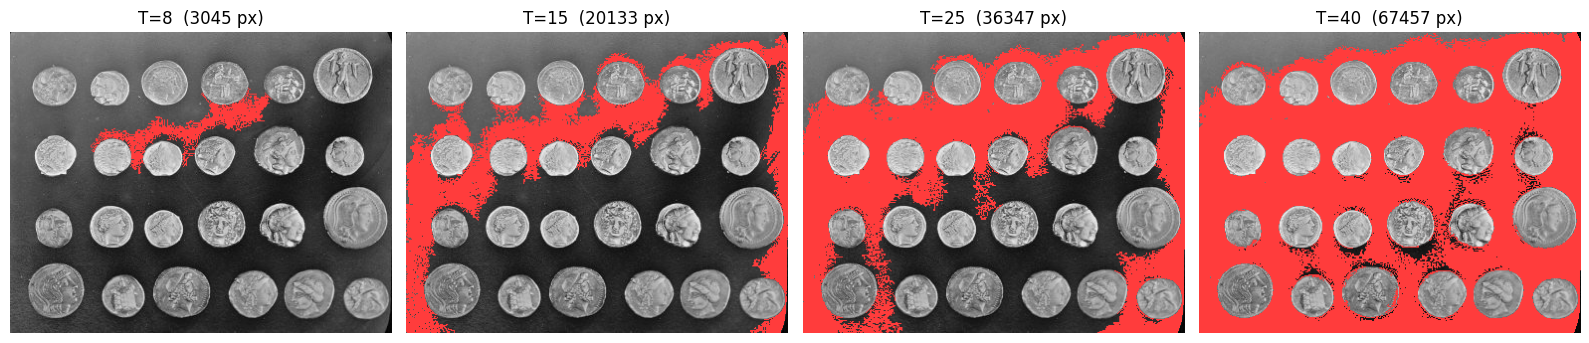

In [7]:
thresholds = [8, 15, 25, 40]

fig, axes = plt.subplots(1, len(thresholds), figsize=(16, 4))
for ax, T in zip(axes, thresholds):
    m = region_growing(image, seed, threshold=T, connectivity=8)
    overlay = np.stack([image] * 3, axis=-1).astype(np.uint8)
    overlay[m] = [255, 60, 60]
    ax.imshow(overlay)
    ax.set_title(f'T={T}  ({m.sum()} px)')
    ax.axis('off')
plt.tight_layout()
plt.show()

**Notes**
- At `T=8` growth stays inside the seeded coin. By `T=25`–`40` it leaks through the weak coin/background boundary and merges with neighboring coins --- exactly the "leaking" failure mode from the Limitations slide.
- Seed placement matters just as much as $T$: try seeding on the background instead of a coin and see how differently the region grows.
- **Multi-seed extension**: to segment the whole image, place a seed in each object of interest and grow all regions (e.g., in round-robin fashion), assigning each pixel to whichever region reaches it first.